<a href="https://colab.research.google.com/github/FrancescaMicu/3DUPB_Computer_Vision/blob/main/proiect3DUPB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import json, random, copy, re, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import deque
warnings.filterwarnings('ignore')
random.seed(42); np.random.seed(42)

In [2]:
# instalare api-uri
!pip install transformers accelerate bitsandbytes matplotlib

#
GRID_W, GRID_H = 16, 16
# codificarea hartii
# Bird -> zona blocata
# Normal Ladder -> pas inainte
# Start -> baza de inceput
# Exit -> Iesirea
# Beetle -> inamicul care trebuie ocolit cu orice pret (altfel se pierde jocul)
# Portal -> te teleporteaza la cealalta iesire a portalului
# Vines -> pas inainte dublu
# Broken Ladder -> coborare cu un rand mai jos fortata
TILE = {
    0:('.','#1a1a2e','Bird'),
    1:('N','#dfe6e9','Normal Ladder'),
    2:('S','#00b894','Start'),
    3:('E','#d63031','Exit'),
    4:('K','#f39c12','Beetle'),
    5:('P','#8e44ad','Portal'),
    6:('V','#c0392b','Vines'),
    7:('B','#f1c40f','Broken Ladder'),
}

PASSABLE = {1, 2, 3, 4, 5, 6, 7}
COLORS = {k:v[1] for k, v in TILE.items()}
ASCII_MAP = {v[0]:k for k, v in TILE.items()}
VALID_CHARS = set(ASCII_MAP.keys())
print(VALID_CHARS)

print('✅ Config OK — Joc: Climb the Tower — Grid:', GRID_W, 'x', GRID_H)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 MB 15.0 MB/s eta 0:00:00
{'.', 'V', 'E', 'S', 'B', 'K', 'P', 'N'}
✅ Config OK — Joc: Climb the Tower — Grid: 16 x 16


In [ ]:
# descarcam LLM-ul

# conectare cu google colab
from google.colab import drive
from huggingface_hub import snapshot_download

drive.mount('/content/drive')

snapshot_download(
    repo_id="HuggingFaceTB/SmolLM2-1.7B-Instruct",
    local_dir="/content/drive/MyDrive/models/smollm2",
    ignore_patterns=["*.msgpack","*.h5","flax_*"],
)

print("✅ Model salvat în Drive!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 28 files:   0%|          | 0/28 [00:00<?, ?it/s]

✅ Model salvat în Drive!


In [3]:
# incarcare din drive
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from google.colab import drive

drive.mount('/content/drive')
MODEL_ID = "/content/drive/MyDrive/models/smollm2"

print(f'🔄 Încărcare model din Drive...')
print(f'   GPU: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

bnb = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, quantization_config=bnb, device_map='auto')
model.eval()
print('✅ Model încărcat din Drive!')

Mounted at /content/drive
🔄 Încărcare model din Drive...
   GPU: True
   VRAM: 15.6 GB


Loading weights:   0%|          | 0/218 [00:00<?, ?it/s]

✅ Model încărcat din Drive!


In [4]:
# generare nivel folosind smollm2

# pregatirea promptului
SYSTEM = """You are a game level designer. Generate a tree-climbing level as ASCII art

Characters: . = Bird, N = Normal Ladder, S = Start, E = Exit, K = Beetle, P = Portal, V = Vines, B = Broken Ladder

Rules:
- Exactly 1 S and 1 E
- The start S must always be in the last row
- The exit E must always be in the first row
- The bird . has the same purpose as a wall
- The beetle K is the enemy, if you step on it the game is over
- If there are portals P, there must always be 2
- One vine gives you a boost so you can skip a row upwards
- The majority of the ladders (N and B) must be connected to form a path upwards, so you can go up on the ladder
- There can be ladders that are connected horizontaly, so you can go left or right on the ladder
- The only way to win the game is to find a path to pass through that respects the rules, there must be a way to get from start to end
- Output ONLY the 16 lines with 16 characters each and no other explanation
          """
USER = """...............E
...NNN.NNNNNNNNN
.....NNNNN......
.....NNNNNN.....
.....NNKNNN....N
.....NNNNN.....N
.....NNNNNNNNNNN
....NNNNNN......
...P..NNNN......
...N..NNNN.V....
...NNNNNNNNN....
...NNNNN........
...NNNNN...B....
...P.NNNNNNN....
...NNNNNN.......
...NNN.SN......

Modify this level to make it more interesting. Output ONLY the 16 lines, with no other text."""

def calling_llm(system, user, temp = 0.4, max_new = 400):
  msgs = [{'role':'system','content':system}, {'role':'user','content':user}]
  txt  = tokenizer.apply_chat_template(msgs, tokenize = False, add_generation_prompt = True)
  inp  = tokenizer(txt, return_tensors='pt').to(model.device)
  with torch.no_grad():
      out = model.generate(**inp, max_new_tokens = max_new, temperature=temp,
              do_sample=True, top_p=0.9,
              pad_token_id=tokenizer.eos_token_id)
  return tokenizer.decode(out[0][inp['input_ids'].shape[1]:], skip_special_tokens=True)

def parse_ascii_permisive(resp):
  lines = []

  # harta trebuie sa aiba exact GRID_W caractere
  for raw_line in resp.strip().split('\n'):
    line = raw_line.strip()
    if not line or len(line) < GRID_W / 4:
      continue
    cleaned = ''.join(c if c in VALID_CHARS else '.' for c in line)
    if len(cleaned) < GRID_W / 2:
      continue
    if len(cleaned) > GRID_W:
      cleaned = cleaned[:GRID_W]

    if len(cleaned) < GRID_W:
      pad = '.'
      cleaned = cleaned + pad * (GRID_W - len(cleaned))

    lines.append([ASCII_MAP.get(c, 1) for c in cleaned])
    if len(lines) == GRID_H:
      break

  # harta are prea putin linii
  while len(lines) < GRID_H:
    lines.append([0] * GRID_W)

  # ne asiguram ca harta are exact cate linii are nevoie
  return lines[:GRID_H]

print('✅ Functii de apel llm si de parsare definite')



✅ Functii de apel llm si de parsare definite


In [29]:
from collections import deque

# functii de parsare
def find_tiles(g, tid):
  hits = []
  for r, row in enumerate(g):
    for c, t in enumerate(row):
      if t == tid:
        hits.append((r,c))
  return hits

def find_tile(g, tid):
    for r, row in enumerate(g):
        for c, t in enumerate(row):
            if t == tid:
              return(r,c)
    return None

# functie de validare prin bfs
# def bfs(g, start, goal, passable, portals):
#   if not start or not goal:
#     return False, 0
#   if start == goal:
#     return True, 0
#   q = deque([(start,0)]);
#   vis = {start}
#   while q:
#     (r, c), d = q.popleft()

#     moves = [(-1, 0), (1, 0), (0, -1), (0, 1)]
#     neighbors = []

#     for dr, dc in moves:
#       # logica de broken ladder
#       if g[r][c] == 7 and dr == -1:
#         continue

#       nr, nc = r + dr, c + dc

#       # logica de normal ladder
#       if g[r][c] == 6 and dr == -1:
#         nr = r - 2

#       neighbors.append((nr, nc))

#     # validare bfs pentru portal
#     if (r, c) in portals and len(portals) == 2:
#       other_portal = portals[1] if portals[0] == (r, c) else portals[0]
#       neighbors.append(other_portal)

#     for nr,nc in neighbors:
#       if not(0 <= nr < GRID_H and 0 <= nc < GRID_W):
#         continue
#       if (nr,nc) in vis:
#         continue
#       if (nr,nc) == goal:
#         return True, d+1
#       if g[nr][nc] in passable:
#         vis.add((nr,nc))
#         q.append(((nr, nc),d+1))
#   return False, 0
def bfs_with_path(g, start, goal, passable, portals):
    if not start or not goal:
        return False, [], 0
    if start == goal:
        return True, [start], 0

    q = deque([(start, 0)])
    vis = {start}
    parent = {start: None}

    while q:
        (r, c), d = q.popleft()

        # 1. Calculăm mișcările posibile conform fizicii
        moves = [(-1, 0), (1, 0), (0, -1), (0, 1)]
        neighbors = []

        for dr, dc in moves:
            # Scara stricată (7) nu te lasă să urci
            if g[r][c] == 7 and dr == -1:
                continue

            nr, nc = r + dr, c + dc

            # Liana (6) te aruncă 2 blocuri în sus
            if g[r][c] == 6 and dr == -1:
                nr = r - 2

            neighbors.append((nr, nc))

        # 2. Logica portalurilor
        if (r, c) in portals and len(portals) == 2:
            other_portal = portals[1] if portals[0] == (r, c) else portals[0]
            if other_portal not in vis:
                vis.add(other_portal)
                parent[other_portal] = (r, c)
                q.append((other_portal, d + 1))

        # 3. Explorăm vecinii
        for nr, nc in neighbors:
            if not (0 <= nr < GRID_H and 0 <= nc < GRID_W):
                continue
            if (nr, nc) in vis:
                continue

            if (nr, nc) == goal:
                parent[(nr, nc)] = (r, c)
                # Reconstruim drumul de la Goal înapoi la Start
                path = []
                curr = (nr, nc)
                while curr is not None:
                    path.append(curr)
                    curr = parent[curr]
                path.reverse()
                return True, path, d + 1

            if g[nr][nc] in passable:
                vis.add((nr, nc))
                parent[(nr, nc)] = (r, c)
                q.append(((nr, nc), d + 1))

    return False, [], 0

# functii de reparare a hartii
def fix_grid(g):
  # conectarea scari in caz de gap
  for c in range(GRID_W):
    ladders = []
    for r in range(GRID_H):
      if g[r][c] in [1, 7]:
        ladders.append(r)

      if len(ladders) >= 2:
        for k in range(len(ladders) - 1):
          r_up = ladders[k]
          r_down = ladders[k+1]
          if r_down - r_up <= 6:
            for r_in_between in range(r_up + 1, r_down):
              if g[r_in_between][c] != 1:
                g[r_in_between][c] = 1

    # corectare start si exit
    for r in range(GRID_H):
      for c in range(GRID_W):
        if g[r][c] in [2, 3]:
                g[r][c] = 1

    g[GRID_H-1][GRID_W//2] = 2
    g[0][GRID_W//2] = 3

    # corectare portaluri
    num_portals = len(find_tiles(g, 5))

    if num_portals > 2:
      for r in range(GRID_H):
        for c in range(GRID_W):
          if num_portals > 2 and g[r][c] == 5:
            g[r][c] = 1
            num_portals -= 1

    elif num_portals == 1:
      # portalul se plaseaza imediat sub iesire
      r, c = find_tile(g, 3)
      g[r + 1][c] = 5

    return g

# functii de testare
# def validate(g):
#   res = {'valid' : False, 'issues' : [], 'metrics' : {}}
#   s = find_tile(g, 2)
#   ex = find_tile(g, 3)
#   portals = find_tiles(g, 5)

#   # cautam existenta startului
#   if not s:
#     res['issues'].append('Lipsă START')
#     return res
#   elif s[0] != GRID_H - 1:
#     res['issues'].append(f'START nu e pe ultimul rând (găsit pe {s[0]})')
#     return res

#   # cautam existenta iesirii
#   if not ex:
#     res['issues'].append('Lipsă EXIT')
#     return res
#   elif ex[0] != 0:
#     res['issues'].append(f'EXIT nu e pe primul rând (găsit pe {ex[0]})')
#     return res

#   # verificam logica de portaluri
#   if len(portals) != 2 and len(portals) != 0:
#     res['issues'].append(f'Număr incorect de portaluri: {len(portals)} (trebuie 0 sau 2)')
#     return res

#   passables = {1, 2, 3, 5, 6, 7}
#   ok, l = bfs(g, s, ex, passables, portals)

#   res['metrics']['path_s_e'] = l if ok else -1
#   res['metrics']['total_path'] = l if ok else 0

#   if not ok:
#     res['issues'].append('S→E blocat (nu se poate ajunge la ieșire)')

#   res['metrics']['beetles'] = sum(1 for r in g for t in r if t == 4)
#   res['metrics']['portals'] = len(portals)
#   res['metrics']['vines'] = sum(1 for r in g for t in r if t == 6)
#   res['metrics']['broken_ladders'] = sum(1 for r in g for t in r if t == 7)
#   res['metrics']['floor'] = sum(1 for r in g for t in r if t in passables)

#   res['valid'] = ok and not res['issues']
#   return res
def validate(g):
    start = find_tile(g, 2)
    goal = find_tile(g, 3)
    portals = find_tiles(g, 5)

    # Piesele pe care jucătorul poate păși
    passable = [1, 2, 3, 4, 5, 6, 7]

    ok, path, dist = bfs_with_path(g, start, goal, passable, portals)

    metrics = {
        'beetles': len(find_tiles(g, 4)),
        'broken_ladders': len(find_tiles(g, 7)),
        'vines': len(find_tiles(g, 6)),
        'total_path': dist if ok else 0,
        'path_beetles': 0,
        'path_broken': 0,
        'path_vines': 0,
        'danger_score': 0
    }

    if not ok:
        return {'valid': False, 'metrics': metrics, 'path': []}

    # ==========================================
    # CALCULĂM ZONA DE PERICOL PE CALEA CRITICĂ
    # ==========================================
    danger_zone = set()
    for r, c in path:
        danger_zone.add((r, c)) # Căsuța de pe traseu
        for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]: # Vecinii imediați
            nr, nc = r + dr, c + dc
            if 0 <= nr < GRID_H and 0 <= nc < GRID_W:
                danger_zone.add((nr, nc))

    # Numărăm doar elementele din zona de pericol
    for r, c in danger_zone:
        tile = g[r][c]
        if tile == 4: metrics['path_beetles'] += 1
        if tile == 7: metrics['path_broken'] += 1
        if tile == 6: metrics['path_vines'] += 1

    # Formula Scoului de Pericol (Gândac = 10 pct, Capcană = 5 pct)
    metrics['danger_score'] = (metrics['path_beetles'] * 10) + (metrics['path_broken'] * 5)

    return {'valid': True, 'metrics': metrics, 'path': path}

# generare harta standard (harta de baza pe care am dat-o modelului)
def fallback_level():
  fallback_ascii = """...............E
...NNN.NNNNNNNNN
.....NNNNN......
.....NNNNNN.....
.....NNKNNN....N
.....NNNNN.....N
.....NNNNNNNNNNN
....NNNNNN......
...P..NNNN......
...N..NNNN.V....
...NNNNNNNNN....
...NNNNN........
...NNNNN...B....
...P.NNNNNNN....
...NNNNNN.......
...NNN.SN......"""

  g = []
  for line in fallback_ascii.strip().split('\n'):
    row = [ASCII_MAP.get(c, 0) for c in line.strip()]
    while len(row) < GRID_W:
      row.append(0)
    g.append(row[:GRID_W])

  while len(g) < GRID_H:
    g.append([0] * GRID_W)

  g = g[:GRID_H]
  return g

print('✅ Funcții BFS, parse, repair, validate definite')


✅ Funcții BFS, parse, repair, validate definite


In [31]:
# generare nivel folosind LLM

MAX_ATTEMPTS = 5
base = None
source = None

for attempt in range(MAX_ATTEMPTS):
  temp = 0.70 + attempt * 0.05
  print(f'\n🔄 Încercarea {attempt+1}/{MAX_ATTEMPTS} (temperature={temp:.2f})...')

  raw = calling_llm(SYSTEM, USER, temp = temp, max_new = 400)

  # Afiseaza primele 3 linii din output pentru debug
  preview = [l.strip() for l in raw.strip().split('\n') if l.strip()][:3]
  print(f'   Preview: {preview}')

  # Parse permisiv
  raw_grid = parse_ascii_permisive(raw)

  # Fixing
  candidate = fix_grid(raw_grid)

  # Validare
  v = validate(candidate)
  print(f'   Jucabil: {"✅" if v["valid"] else "❌"}  |  metrics={v["metrics"]}')

  if v['valid']:
    base = candidate
    source = f'LLM (încercarea {attempt + 1}, temp={temp:.2f})'
    print(f'   🎉 Nivel valid obținut!')
    break

# Fallback daca toate incercarile au eșuat
if base is None:
    print('\n⚠️  Toate încercările au eșuat → fallback procedural')
    base   = fallback_level()
    source = 'Fallback procedural'

v_final = validate(base)
print(f'\n✅ Nivel final ({source})')
print(f'   Jucabil: {"✅" if v_final["valid"] else "❌"}  |  {v_final["metrics"]}')
print('\nASCII map:')
for row in base:
  print(''.join(TILE[t][0] if t in TILE else '?' for t in row))



🔄 Încercarea 1/5 (temperature=0.70)...
   Preview: ['...............E', '...NNN.NNNNN', '.....NNN.N.N']
   Jucabil: ✅  |  metrics={'beetles': 2, 'broken_ladders': 0, 'vines': 0, 'total_path': 17, 'path_beetles': 0, 'path_broken': 0, 'path_vines': 0, 'danger_score': 0}
   🎉 Nivel valid obținut!

✅ Nivel final (LLM (încercarea 1, temp=0.70))
   Jucabil: ✅  |  {'beetles': 2, 'broken_ladders': 0, 'vines': 0, 'total_path': 17, 'path_beetles': 0, 'path_broken': 0, 'path_vines': 0, 'danger_score': 0}

ASCII map:
........E......N
...NNN.NNNNN....
.....NNN.N.N....
.....NNN.N.N....
...K.N.N.N.N....
...NNN.N.N.N....
...N.N.N...N....
...NNN.N.N.N....
...NNN.N.N.N....
...K.N.N.N.N....
...NNN.N.N.N....
...N.N.N...N....
...N.N.N.N.N....
...N.N.N.N.N....
...N.N.N...N....
...N.N.NSN.N....


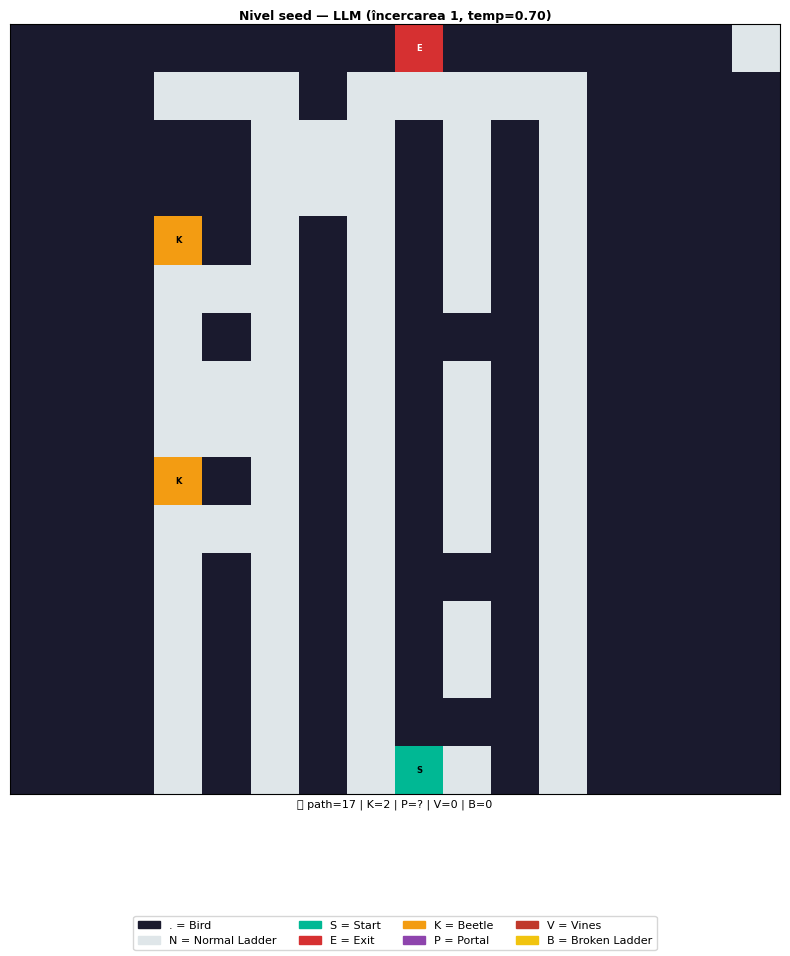

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# vizualizare nivel
def draw_level(ax, g, title='', val=None):
  H, W = len(g), len(g[0])
  img = np.zeros((H, W, 3))

  for r in range(H):
    for c in range(W):
      hx = COLORS.get(g[r][c], '#888')
      img[r, c] = [int(hx[1:3], 16)/255, int(hx[3:5], 16)/255, int(hx[5:7], 16)/255]

  ax.imshow(img, interpolation='nearest', aspect='equal')

  for r in range(H):
    for c in range(W):
      t = g[r][c]
      if t not in(0, 1):
        ax.text(c, r, TILE[t][0], ha='center', va='center', fontsize=6,
                        fontweight='bold', color='black' if t in (2, 4, 7) else 'white')

  ax.set_title(title, fontsize=9, fontweight='bold', pad=3)

  if val:
    m = val['metrics']
    ok = '✅' if val['valid'] else '❌'
    stats = (f"{ok} path={m.get('total_path','?')} | "
                 f"K={m.get('beetles','?')} | "
                 f"P={m.get('portals','?')} | "
                 f"V={m.get('vines','?')} | "
                 f"B={m.get('broken_ladders','?')}")
    ax.set_xlabel(stats, fontsize=8)

  ax.set_xticks([])
  ax.set_yticks([])

fig, ax = plt.subplots(figsize=(8, 10))
draw_level(ax, base, f'Nivel seed — {source}', v_final)

patches = [mpatches.Patch(color=COLORS[k], label=f"{TILE[k][0]} = {TILE[k][2]}") for k in sorted(TILE)]
fig.legend(handles=patches, loc='lower center', ncol=4, fontsize=8)

plt.tight_layout()
plt.subplots_adjust(bottom=0.1)
plt.show()

# **Implementare Algoritmi Genetici**

In [36]:
# definire nivel usor
# def fit_easy(g):
#   v = validate(g)
#   if not v['valid']:
#     return -1000.
#   m = v['metrics']
#   # maxim 5 vines
#   vines = min(m.get('vines', 0), 5)
#   return (3.0 * m.get('total_path', 0)
#           - 5.0 * m.get('beetles', 0)
#           - 15.0 * m.get('broken_ladders', 0)
#           + 5.0 * vines)

# definire nivel mediu
# def fit_medium(g):
#   v = validate(g)
#   if not v['valid']:
#     return -1000.
#   m = v['metrics']
#   # 3 beetles, 1-2 broken ladders
#   beetles = max(m.get('beetles', 0), 6)
#   return (-2.0 * abs(m.get('total_path', 0) - 25)
#           - 3.0 * abs(beetles - 3)
#           - 4.0 * abs(m.get('broken_ladders', 0) - 1)
#           + 2.0 * m.get('vines', 0))

# # definire nivel greu
# def fit_hard(g):
#   v = validate(g)
#   if not v['valid']:
#     return -1000.
#   m = v['metrics']
#   # maxim 6 beetles, 4 broken ladders
#   beetles = min(m.get('beetles', 0), 6)
#   broken_ladders = min(m.get('broken_ladders', 0), 4)
#   return (5.0 * beetles
#           + 8.0 * broken_ladders
#           - 1.0 * m.get('total_path', 0))
def fit_easy(g):
    v = validate(g)
    if not v['valid']:
        return -500  # Penalizare severă pentru hărți blocate

    m = v['metrics']
    score = 100

    # Vrem zero pericol pe traseu și multe liane ajutătoare
    score -= m['danger_score'] * 5
    score += min(m['path_vines'], 4) * 15

    return score


def fit_medium(g):
    v = validate(g)
    if not v['valid']:
        return -500  # Penalizare severă pentru hărți blocate

    m = v['metrics']
    score = 100

    # Vrem pericol moderat (Danger Score țintă: 15 - 25)
    target_danger = 20
    score -= abs(m['danger_score'] - target_danger) * 4
    score += min(m['path_vines'], 2) * 10

    return score


def fit_hard(g):
    v = validate(g)
    if not v['valid']:
        return -500

    m = v['metrics']
    score = 100

    # 1. LIMITA ANTI-SPAM (Maximum 15 pericole)
    total_hazards = m.get('beetles', 0) + m.get('broken_ladders', 0)
    if total_hazards > 15:
        # Penalizare severă pentru fiecare inamic pus în plus față de 15
        score -= (total_hazards - 15) * 30

    # 2. Recompensăm Danger Score-ul, dar îl plafonăm (ex: max 50 puncte adăugate)
    # ca să nu mai aibă motiv să pună pericole la infinit
    score += min(m.get('danger_score', 0), 40) * 3

    score += m.get('total_path', 0) * 2
    score -= m.get('path_vines', 0) * 10

    return score

FIT = {'easy':fit_easy,'medium':fit_medium,'hard':fit_hard}

# def mutate(g, rate=0.05, diff='medium'):
#   c = copy.deepcopy(g)

#   # Tile pool fără tile-uri speciale care trebuie să fie unice
#   pool = {
#       'easy':   [1, 1, 1, 1, 0, 6],       # Mai multe normal ladders și vianes
#       'medium': [1, 1, 0, 4, 6, 7],       # Mix echilibrat
#       'hard':   [1, 0, 0, 4, 4, 7, 7],    # Beetles și broken ladders
#   }.get(diff, [1, 1, 0, 6, 7])

#   for r in range(1, GRID_H-1):
#     for col in range(1, GRID_W-1):
#       t = c[r][col]
#       if t in (2, 3, 5):
#         continue    # nu atinge start/exit/portals
#       if random.random() < rate:
#         new_tile = random.choice(pool)

#         # broken ladder, vines si beetle sa fie cat mai aproape de
#         # scara principala pentru a face jocul mai captivant
#         if new_tile in [4, 6, 7]:
#           vecini = [
#                     c[r-1][col],
#                     c[r+1][col],
#                     c[r][col-1],
#                     c[r][col+1]
#                     ]

#           if 1 in vecini or t == 1:
#             c[r][col] = new_tile
#           else:
#             c[r][col] = new_tile

#   c = fix_grid(c)
#   return c

def mutate(g, rate=0.05, diff='medium'):
    c = copy.deepcopy(g)

    # Tile pool fără tile-uri speciale care trebuie să fie unice
    pool = {
        'easy':   [1, 1, 1, 1, 0, 6],       # Mai multe normal ladders și vines
        'medium': [1, 1, 0, 4, 6, 7],       # Mix echilibrat
        'hard':   [1, 0, 0, 4, 4, 7, 7],    # Beetles și broken ladders agresive
    }.get(diff, [1, 1, 0, 6, 7])

    for r in range(1, GRID_H-1):
        for col in range(1, GRID_W-1):
            t = c[r][col]

            if t in (2, 3, 5):
                continue    # Nu atinge start/exit/portals

            if random.random() < rate:
                new_tile = random.choice(pool)

                # 1. Spațiile goale (0) și Scările normale (1) se pot pune oriunde
                if new_tile in [0, 1]:
                    c[r][col] = new_tile
                    continue

                # 2. Extragem vecinii pentru piesele speciale
                vecini = [
                    c[r-1][col], # Sus
                    c[r+1][col], # Jos
                    c[r][col-1], # Stânga
                    c[r][col+1]  # Dreapta
                ]

                # 3. Regula Gândacilor(4) și Scărilor Stricate(7) -> Distanțare Socială
                if new_tile in [4, 7]:
                    # Condiție: Să fie lângă drum/pe drum ȘI să nu atingă alți inamici!
                    if (1 in vecini or t == 1) and (4 not in vecini) and (7 not in vecini):
                        c[r][col] = new_tile

                # 4. Regula Lianelor(6) -> Pot sta lipite între ele, doar să fie lângă drum
                elif new_tile == 6:
                    if 1 in vecini or t == 1:
                        c[r][col] = new_tile

    c = fix_grid(c)
    return c

def crossover(g1,g2):
  p1 = random.randint(1,GRID_H//3)
  p2 = random.randint(GRID_H//3*2,GRID_H-2)
  child = [copy.deepcopy(g1[r]) if r<p1 or r>p2 else copy.deepcopy(g2[r]) for r in range(GRID_H)]
  c = fix_grid(child)
  return c

def tournament(pop,scores,k=3):
  cands=random.sample(list(zip(pop,scores)),min(k,len(pop)))
  return max(cands,key=lambda x:x[1])[0]

def run_ga(seed, diff, pop_size=20, gens=30, elite=3):
  fn = FIT[diff]
  pop = [seed] + [mutate(seed, rate=0.08, diff=diff) for _ in range(pop_size-1)]
  history=[]
  for g in range(gens):
    scores = [fn(ind) for ind in pop]
    history.append(max(scores))
    if g%10 == 0 or g == gens-1:
      valid_n = sum(1 for s in scores if s>-1000)
      print(f'  [{diff}] gen={g:3d} best={max(scores):8.2f} valid={valid_n}/{pop_size}')

    pairs = sorted(zip(scores,pop), key=lambda x:-x[0])
    new = [copy.deepcopy(ind) for _,ind in pairs[:elite]]
    while len(new) < pop_size:
      p1 = tournament(pop, scores)
      child = crossover(p1, tournament(pop,scores)) if random.random()<0.6 else copy.deepcopy(p1)
      new.append(mutate(child,diff=diff))
    pop = new
  final = [fn(ind) for ind in pop]
  best = pop[int(np.argmax(final))]
  return best, history

# testare pe harta generata de llm
ga_results = {}
ga_histories = {}
for diff in['easy', 'medium', 'hard']:
  print(f'\n🧬 GA [{diff.upper()}]')

  best, hist = run_ga(base, diff)
  ga_results[diff] = best
  ga_histories[diff] = hist
  v = validate(best)

  print(f'   ✅ valid={v["valid"]} | {v["metrics"]}')
print('\n🏁 GA complet!')



🧬 GA [EASY]
  [easy] gen=  0 best=  130.00 valid=20/20
  [easy] gen= 10 best=  160.00 valid=20/20
  [easy] gen= 20 best=  160.00 valid=20/20
  [easy] gen= 29 best=  160.00 valid=20/20
   ✅ valid=True | {'beetles': 2, 'broken_ladders': 0, 'vines': 6, 'total_path': 16, 'path_beetles': 0, 'path_broken': 0, 'path_vines': 4, 'danger_score': 0}

🧬 GA [MEDIUM]
  [medium] gen=  0 best=  110.00 valid=20/20
  [medium] gen= 10 best=  120.00 valid=20/20
  [medium] gen= 20 best=  120.00 valid=20/20
  [medium] gen= 29 best=  120.00 valid=20/20
   ✅ valid=True | {'beetles': 6, 'broken_ladders': 1, 'vines': 4, 'total_path': 16, 'path_beetles': 2, 'path_broken': 0, 'path_vines': 2, 'danger_score': 20}

🧬 GA [HARD]
  [hard] gen=  0 best=  209.00 valid=20/20
  [hard] gen= 10 best=  270.00 valid=20/20
  [hard] gen= 20 best=  270.00 valid=20/20
  [hard] gen= 29 best=  270.00 valid=20/20
   ✅ valid=True | {'beetles': 8, 'broken_ladders': 7, 'vines': 0, 'total_path': 25, 'path_beetles': 5, 'path_broken': 2,

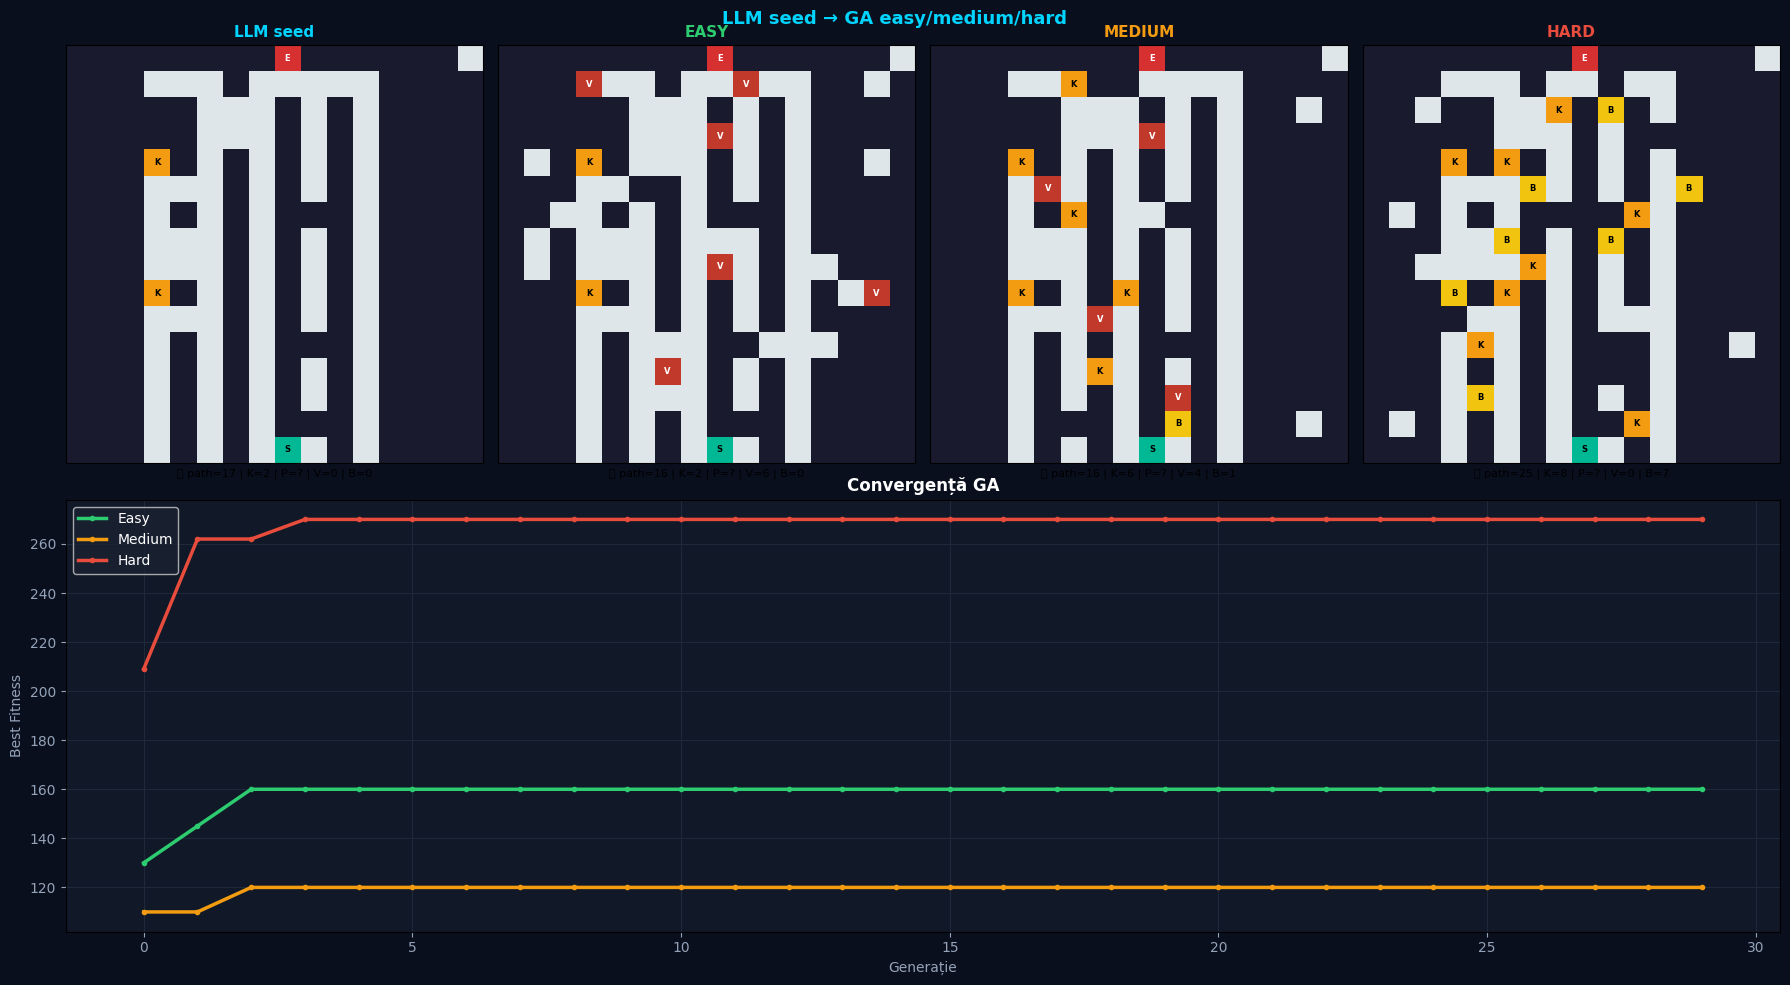

✅ Niveluri selectate pentru Q-Learning:
  easy: valid=True | {'beetles': 2, 'broken_ladders': 0, 'vines': 6, 'total_path': 16, 'path_beetles': 0, 'path_broken': 0, 'path_vines': 4, 'danger_score': 0}
  medium: valid=True | {'beetles': 6, 'broken_ladders': 1, 'vines': 4, 'total_path': 16, 'path_beetles': 2, 'path_broken': 0, 'path_vines': 2, 'danger_score': 20}
  hard: valid=True | {'beetles': 8, 'broken_ladders': 7, 'vines': 0, 'total_path': 25, 'path_beetles': 5, 'path_broken': 2, 'path_vines': 0, 'danger_score': 60}


In [37]:
# vizuarilizare niveluri create
fig = plt.figure(figsize=(18,10))
fig.patch.set_facecolor('#0A0F1E')
DCOL = {'easy':'#2ecc71','medium':'#f39c12','hard':'#e74c3c'}

all_lv = [('LLM seed',base,'#00D4FF')] + [(d.upper(),ga_results[d],DCOL[d]) for d in['easy','medium','hard']]
for i, (lbl,g,col) in enumerate(all_lv):
    ax = fig.add_subplot(2,4,i+1); ax.set_facecolor('#0A0F1E')
    draw_level(ax,g,lbl,validate(g))
    ax.set_title(lbl,color=col,fontsize=11,fontweight='bold')

ax2 = fig.add_subplot(2,4,(5,8))
ax2.set_facecolor('#111827')
for diff,col in DCOL.items():
    ax2.plot(ga_histories[diff],color=col,lw=2.5,label=diff.capitalize(),marker='o',ms=3)

ax2.set_title('Convergență GA',color='white',fontsize=12,fontweight='bold')
ax2.set_xlabel('Generație',color='#94A3B8')
ax2.set_ylabel('Best Fitness',color='#94A3B8')

ax2.legend(fontsize=10,facecolor='#1A2333',labelcolor='white')
ax2.grid(True,color='#1E293B')
ax2.tick_params(colors='#94A3B8')
plt.suptitle('LLM seed → GA easy/medium/hard',color='#00D4FF',fontsize=13,fontweight='bold')
plt.tight_layout()
plt.show()

ql_levels = {d:ga_results[d] for d in['easy','medium','hard']}
print('✅ Niveluri selectate pentru Q-Learning:')
for d,g in ql_levels.items():
    v = validate(g)
    print(f'  {d}: valid={v["valid"]} | {v["metrics"]}')
